<a href="https://colab.research.google.com/github/yoursmaddyy/deep-learning-playground/blob/main/Simulated_Annealing_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

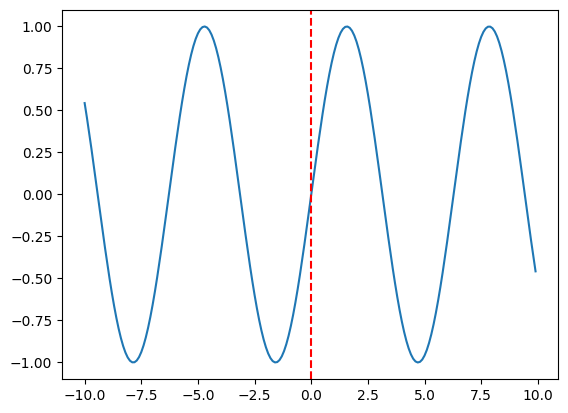

In [19]:
from numpy import arange
from matplotlib import pyplot
import math

def objective(x):
    return math.sin(x[0])

r_min, r_max = -10.0, 10.0
inputs = arange(r_min, r_max, 0.1)
results = [objective([x]) for x in inputs]

pyplot.plot(inputs, results)
pyplot.axvline(x=0.0, ls='--', color='red')
pyplot.show()

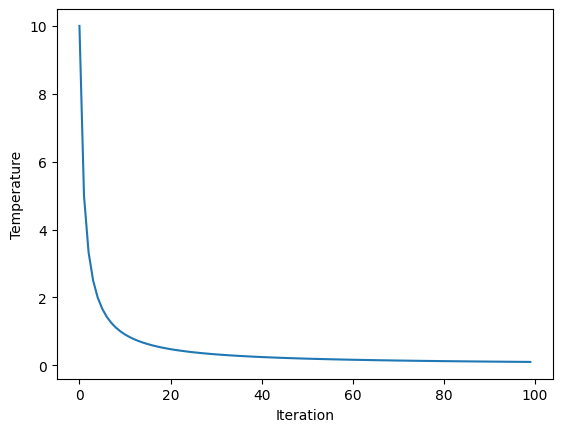

In [13]:
from matplotlib import pyplot

iterations = 100
initial_temp = 10
iterations = [i for i in range(iterations)]
temperatures = [initial_temp / float(i + 1) for i in iterations]

pyplot.plot(iterations, temperatures)
pyplot.xlabel('Iteration')
pyplot.ylabel('Temperature')
pyplot.show()

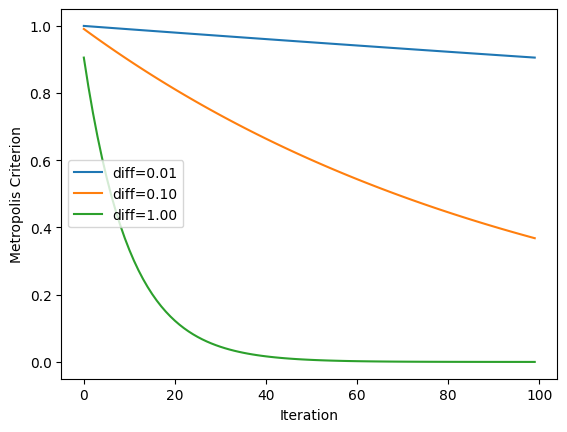

In [14]:
from math import exp
from matplotlib import pyplot

iterations = 100
initial_temp = 10
iterations = [i for i in range(iterations)]
temperatures = [initial_temp / float(i + 1) for i in iterations]

differences = [0.01, 0.1, 1.0]
for d in differences:
    metropolis = [exp(-d / t) for t in temperatures]
    label = 'diff=%.2f' % d
    pyplot.plot(iterations, metropolis, label=label)

pyplot.xlabel('Iteration')
pyplot.ylabel('Metropolis Criterion')
pyplot.legend()
pyplot.show()

>Iteration 34 f([-0.78753544]) = 0.62021
>Iteration 35 f([-0.76914239]) = 0.59158
>Iteration 37 f([-0.68574854]) = 0.47025
>Iteration 39 f([-0.64797564]) = 0.41987
>Iteration 40 f([-0.58914623]) = 0.34709
>Iteration 41 f([-0.55446029]) = 0.30743
>Iteration 42 f([-0.41775702]) = 0.17452
>Iteration 43 f([-0.35038542]) = 0.12277
>Iteration 50 f([-0.15799045]) = 0.02496
>Iteration 66 f([-0.11089772]) = 0.01230
>Iteration 67 f([-0.09238208]) = 0.00853
>Iteration 72 f([-0.09145261]) = 0.00836
>Iteration 75 f([-0.05129162]) = 0.00263
>Iteration 93 f([-0.02854417]) = 0.00081
>Iteration 144 f([0.00864136]) = 0.00007
>Iteration 149 f([0.00753953]) = 0.00006
>Iteration 167 f([-0.00640394]) = 0.00004
>Iteration 225 f([-0.00044965]) = 0.00000
>Iteration 503 f([-0.00036261]) = 0.00000
>Iteration 512 f([0.00013605]) = 0.00000

Done!
f([0.00013605]) = 0.000000


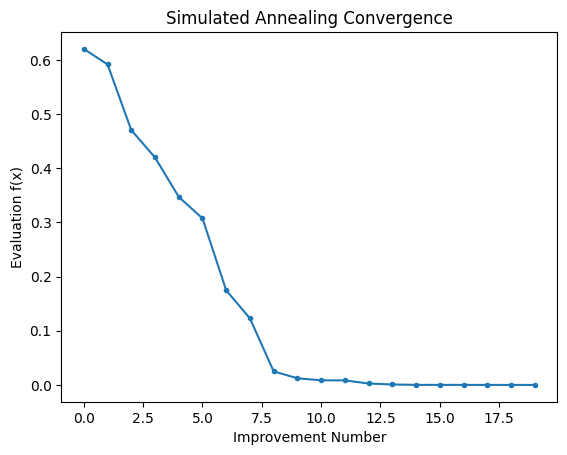

In [15]:
from numpy import asarray, exp
from numpy.random import randn, rand, seed
from matplotlib import pyplot
import numpy as np

def objective(x):
    return x[0] ** 2.0

def simulated_annealing(objective, bounds, n_iterations, step_size, temp):
    best = bounds[:, 0] + rand(len(bounds)) * (bounds[:, 1] - bounds[:, 0])
    best_eval = objective(best)
    curr, curr_eval = best.copy(), best_eval
    scores = []

    for i in range(n_iterations):
        candidate = curr + randn(len(bounds)) * step_size
        candidate = np.clip(candidate, bounds[:, 0], bounds[:, 1])
        candidate_eval = objective(candidate)

        if candidate_eval < best_eval:
            best, best_eval = candidate.copy(), candidate_eval
            scores.append(best_eval)
            print('>Iteration %d f(%s) = %.5f' % (i, best, best_eval))

        diff = candidate_eval - curr_eval
        t = temp / float(i + 1)
        metropolis = exp(-diff / t)

        if diff < 0 or rand() < metropolis:
            curr, curr_eval = candidate.copy(), candidate_eval

    return best, best_eval, scores

# Main
seed(1)
bounds = asarray([[-5.0, 5.0]])
n_iterations = 1000
step_size = 0.1
temp = 10

best, score, scores = simulated_annealing(objective, bounds, n_iterations, step_size, temp)
print('\nDone!')
print('f(%s) = %f' % (best, score))

pyplot.plot(scores, '.-')
pyplot.xlabel('Improvement Number')
pyplot.ylabel('Evaluation f(x)')
pyplot.title('Simulated Annealing Convergence')
pyplot.show()

In [16]:
from numpy import asarray, exp
from numpy.random import randn, rand, seed
import numpy as np

def objective(x):
    return x[0] ** 3

def simulated_annealing(objective, bounds, n_iterations, step_size, temp):
    best = bounds[:, 0] + rand(len(bounds)) * (bounds[:, 1] - bounds[:, 0])
    best_eval = objective(best)
    curr, curr_eval = best.copy(), best_eval

    for i in range(n_iterations):
        candidate = curr + randn(len(bounds)) * step_size
        candidate = np.clip(candidate, bounds[:, 0], bounds[:, 1])
        candidate_eval = objective(candidate)

        if candidate_eval < best_eval:
            best, best_eval = candidate.copy(), candidate_eval
            print('>Iteration %d f(%s) = %.6f' % (i, best, best_eval))

        diff = candidate_eval - curr_eval
        t = temp / float(i + 1)
        metropolis = exp(-diff / t)

        if diff < 0 or rand() < metropolis:
            curr, curr_eval = candidate.copy(), candidate_eval

    return best, best_eval

# Main
seed(1)
bounds = asarray([[-1.0, 1.0]])
n_iterations = 1000
step_size = 0.1
temp = 10

best, score = simulated_annealing(objective, bounds, n_iterations, step_size, temp)
print('Best solution: x = %.6f' % best[0])
print('Minimum value: f(x) = %.6f' % score)

>Iteration 0 f([-0.24617327]) = -0.014918
>Iteration 1 f([-0.29106106]) = -0.024658
>Iteration 2 f([-0.40165456]) = -0.064797
>Iteration 3 f([-0.56710611]) = -0.182387
>Iteration 4 f([-0.80345297]) = -0.518658
>Iteration 16 f([-0.8381959]) = -0.588893
>Iteration 18 f([-0.92320114]) = -0.786845
>Iteration 20 f([-0.93549016]) = -0.818687
>Iteration 21 f([-1.]) = -1.000000
Best solution: x = -1.000000
Minimum value: f(x) = -1.000000


In [17]:
import math, random, numpy as np, time

class Rastrigin:
    def __init__(self, n_dims=2, lower=-5.12, upper=5.12):
        self.n_dims = n_dims
        self.lower = lower
        self.upper = upper

    def baseline_solution(self):
        return np.random.uniform(self.lower, self.upper, self.n_dims)

    def score_solution(self, solution):
        A = 10
        return A * self.n_dims + sum(
            x**2 - A * math.cos(2 * math.pi * x) for x in solution
        )

    def select_neighbor(self, solution):
        neighbor = solution.copy()
        index = random.randint(0, self.n_dims - 1)
        neighbor[index] += random.uniform(-0.5, 0.5)
        neighbor[index] = max(self.lower, min(self.upper, neighbor[index]))
        return neighbor

class SimulatedAnnealing:
    def __init__(self, problem):
        self.problem = problem

    def run(self, max_iterations=5000, initial_temp=100, cooling_rate=0.995):
        current_solution = self.problem.baseline_solution()
        current_obj = self.problem.score_solution(current_solution)
        best_solution = current_solution.copy()
        best_obj = current_obj
        temperature = initial_temp

        for iteration in range(max_iterations):
            neighbor = self.problem.select_neighbor(current_solution)
            neighbor_obj = self.problem.score_solution(neighbor)
            diff = neighbor_obj - current_obj

            if diff < 0 or random.random() < math.exp(-diff / temperature):
                current_solution = neighbor
                current_obj = neighbor_obj

            if current_obj < best_obj:
                best_solution = current_solution.copy()
                best_obj = current_obj

            temperature *= cooling_rate
            if temperature < 1e-8:
                break

        return best_solution, best_obj

# Main
if __name__ == "__main__":
    random.seed(42)
    np.random.seed(42)
    problem = Rastrigin(n_dims=2)
    sa = SimulatedAnnealing(problem)
    start = time.time()
    solution, objective = sa.run()
    end = time.time()
    print("Best Solution Found:", solution)
    print("Best Objective Value:", round(objective, 4))
    print("Execution Time:", round(end - start, 4), "seconds")

Best Solution Found: [0.06707283 0.01724932]
Best Objective Value: 0.9384
Execution Time: 0.0278 seconds


In [21]:
import random, math, time
import matplotlib.pyplot as plt
import numpy as np

def objective(x):
    return x**4 - 3*x**3 + 2

def simulated_annealing(max_iterations=5000, initial_temp=10,
                         cooling_rate=0.995, lower=-1, upper=1):
    current_x = random.uniform(lower, upper)
    current_value = objective(current_x)
    best_x, best_value = current_x, current_value
    temperature = initial_temp

    path = []  # store search path

    for iteration in range(max_iterations):
        path.append((current_x, current_value))

        new_x = max(lower, min(upper, current_x + random.uniform(-0.1, 0.1)))
        new_value = objective(new_x)
        delta = new_value - current_value

        if delta < 0 or random.random() < math.exp(-delta / temperature):
            current_x, current_value = new_x, new_value

        if current_value < best_value:
            best_x, best_value = current_x, current_value

        temperature *= cooling_rate
        if temperature < 1e-8:
            break

    return best_x, best_value, path

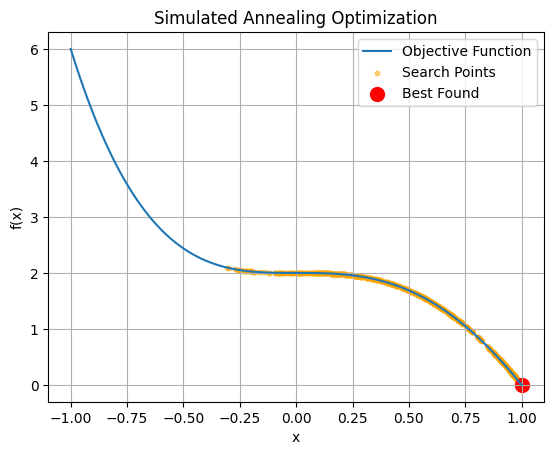

In [22]:
if __name__ == "__main__":
    random.seed(42)
    best_x, best_val, path = simulated_annealing()

    # Generate smooth curve
    x_vals = np.linspace(-1, 1, 400)
    y_vals = [objective(x) for x in x_vals]

    # Plot function
    plt.plot(x_vals, y_vals, label="Objective Function")

    # Plot search path
    path_x = [p[0] for p in path]
    path_y = [p[1] for p in path]
    plt.scatter(path_x, path_y, color='orange', s=10, alpha=0.5, label="Search Points")

    # Highlight best point
    plt.scatter(best_x, best_val, color='red', s=100, label="Best Found")

    plt.title("Simulated Annealing Optimization")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid()
    plt.show()

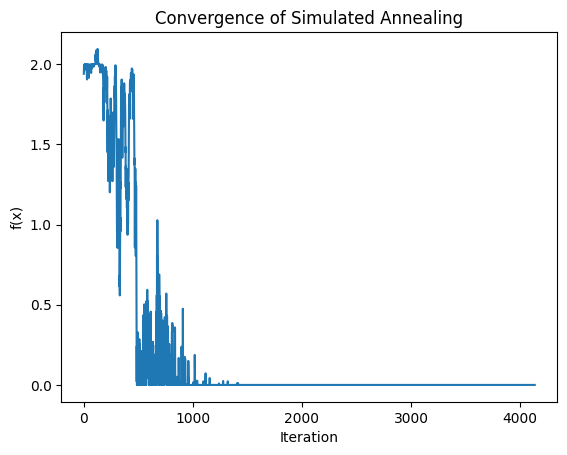

In [23]:
values = [p[1] for p in path]
plt.plot(values)
plt.title("Convergence of Simulated Annealing")
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.show()

In [25]:
import random, math, time
import matplotlib.pyplot as plt
import numpy as np

def objective(x):
    return 10 + x**2 - 10 * math.cos(2 * math.pi * x)

def simulated_annealing(max_iterations=5000, initial_temp=10,
                         cooling_rate=0.995, lower=-5.12, upper=5.12):
    current_x = random.uniform(lower, upper)
    current_value = objective(current_x)
    best_x, best_value = current_x, current_value
    temperature = initial_temp

    path = []  # store search path

    for iteration in range(max_iterations):
        path.append((current_x, current_value))

        new_x = max(lower, min(upper, current_x + random.uniform(-0.1, 0.1)))
        new_value = objective(new_x)
        delta = new_value - current_value

        if delta < 0 or random.random() < math.exp(-delta / temperature):
            current_x, current_value = new_x, new_value

        if current_value < best_value:
            best_x, best_value = current_x, current_value

        temperature *= cooling_rate
        if temperature < 1e-8:
            break

    return best_x, best_value, path

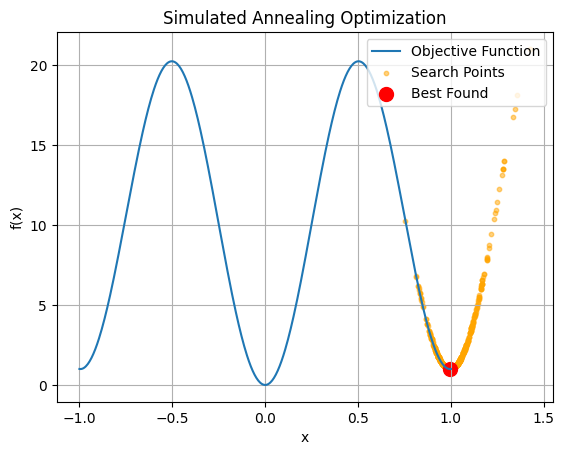

In [26]:
if __name__ == "__main__":
    random.seed(42)
    best_x, best_val, path = simulated_annealing()

    # Generate smooth curve
    x_vals = np.linspace(-1, 1, 400)
    y_vals = [objective(x) for x in x_vals]

    # Plot function
    plt.plot(x_vals, y_vals, label="Objective Function")

    # Plot search path
    path_x = [p[0] for p in path]
    path_y = [p[1] for p in path]
    plt.scatter(path_x, path_y, color='orange', s=10, alpha=0.5, label="Search Points")

    # Highlight best point
    plt.scatter(best_x, best_val, color='red', s=100, label="Best Found")

    plt.title("Simulated Annealing Optimization")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid()
    plt.show()